In [29]:
import pandas as pd
import numpy as np

DATA_PATH = "../data/UCI_dataset/"

X_train = pd.read_csv(DATA_PATH + "train/X_train.txt", sep=r'\s+', header=None).values
X_test  = pd.read_csv(DATA_PATH + "test/X_test.txt",  sep=r'\s+', header=None).values

y_train = pd.read_csv(DATA_PATH + "train/y_train.txt", header=None).values.flatten()
y_test  = pd.read_csv(DATA_PATH + "test/y_test.txt",  header=None).values.flatten()


labels_df = pd.read_csv(DATA_PATH + "activity_labels.txt", sep=' ', header=None)
LABELS = labels_df[1].tolist()

print("X_train shape:", X_train.shape)
print("X_test shape:",  X_test.shape)
print("Activités:", LABELS)

X_train shape: (7352, 561)
X_test shape: (2947, 561)
Activités: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


In [30]:
print(np.unique(y_train))

[1 2 3 4 5 6]


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input



# begin from 0-5
y_train = y_train - 1
y_test  = y_test  - 1

# One-hot encoding ex : 2= [0, 0, 1, 0, 0, 0] vector in R^num_classes
y_train_cat = to_categorical(y_train, num_classes=6)
y_test_cat  = to_categorical(y_test,  num_classes=6)


# Reshape for LSTM : (samples, timesteps, features)
X_train_lstm = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_lstm  = X_test.reshape(X_test.shape[0],   1, X_test.shape[1])


model1 = Sequential([
    Input(shape=(1, 561)),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])

model2 = Sequential([
    Input(shape=(1, 561)),
    LSTM(128),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])



model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:

def plot_curves(history):
    plt.figure(figsize=(12,8))

    plt.plot(history.history['loss'],     label='Train loss')
    plt.plot(history.history['accuracy'],     label='Train accuracy')

    plt.plot(history.history['val_loss'], label='Test loss')
    plt.plot(history.history['val_accuracy'], label='Test accuracy')

    plt.title("Training session's progress over iteration")
    plt.legend(loc = 'upper right', shadow = True)
    plt.ylabel('Training Progress(Loss or Accuracy values)')
    plt.xlabel('Training Epoch')
    plt.ylim(0)

    plt.show()



def plot_cm(model):
    y_pred = np.argmax(model.predict(X_test_lstm), axis=1)
    cm = metrics.confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=LABELS, yticklabels=LABELS)
    plt.title("Matrice de confusion")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png")
    plt.show()

In [32]:
history1 = model1.fit(
    X_train_lstm, y_train_cat,
    epochs=50,
    batch_size=1024,
    validation_data=(X_test_lstm, y_test_cat),
    verbose=1
)

loss1, acc1 = model1.evaluate(X_test_lstm, y_test_cat, verbose=0)
print(f"\nAccuracy : {acc1*100:.2f}%")
print(f"Loss : {loss1*100:.2f}%")

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.2884 - loss: 1.7320 - val_accuracy: 0.3512 - val_loss: 1.5990
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3685 - loss: 1.5030 - val_accuracy: 0.3570 - val_loss: 1.3351
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4211 - loss: 1.2595 - val_accuracy: 0.4605 - val_loss: 1.1073
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5477 - loss: 1.0497 - val_accuracy: 0.5925 - val_loss: 0.9076
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6889 - loss: 0.8648 - val_accuracy: 0.7445 - val_loss: 0.7401
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7729 - loss: 0.7053 - val_accuracy: 0.8066 - val_loss: 0.5970
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8206 - loss: 0.5631 - val_accuracy: 0.8039 - val_loss: 0.4829
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8463 - loss: 0.4491 - val_accuracy: 0.8778 - val_loss: 0.3525


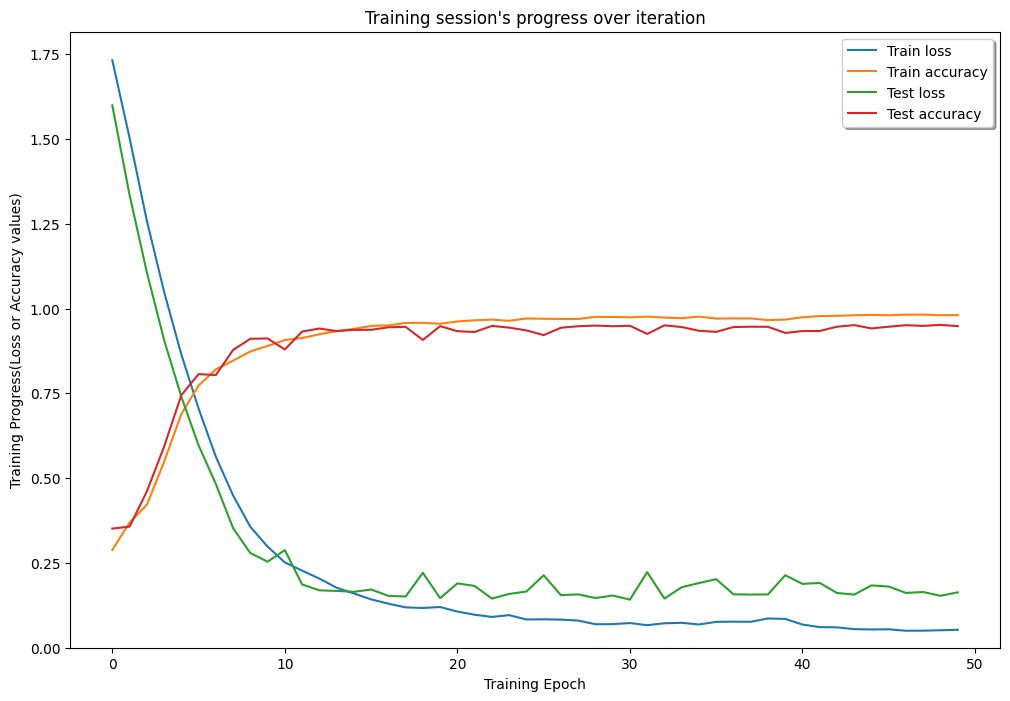

In [34]:
plot_curves(history=history1)

In [35]:
history2 = model2.fit(
    X_train_lstm, y_train_cat,
    epochs=300,
    batch_size=512,
    validation_data=(X_test_lstm, y_test_cat),
    verbose=1
)

loss2, acc2 = model2.evaluate(X_test_lstm, y_test_cat, verbose=0)
print(f"\nAccuracy : {acc2*100:.2f}%")
print(f"Loss : {loss2*100:.2f}%")

Epoch 1/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4856 - loss: 1.2696 - val_accuracy: 0.7669 - val_loss: 0.8377
Epoch 2/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7817 - loss: 0.6662 - val_accuracy: 0.8680 - val_loss: 0.4615
Epoch 3/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8696 - loss: 0.3852 - val_accuracy: 0.9135 - val_loss: 0.3115
Epoch 4/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9013 - loss: 0.2721 - val_accuracy: 0.8941 - val_loss: 0.2637
Epoch 5/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9251 - loss: 0.2045 - val_accuracy: 0.8894 - val_loss: 0.2468
Epoch 6/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9350 - loss: 0.1754 - val_accuracy: 0.9274 - val_loss: 0.1943
Epoch 7/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9465 - loss: 0.1448 - val_accuracy: 0.9335 - val_loss: 0.1770
Epoch 8/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9527 - loss: 0.1259 - val_accuracy: 0.

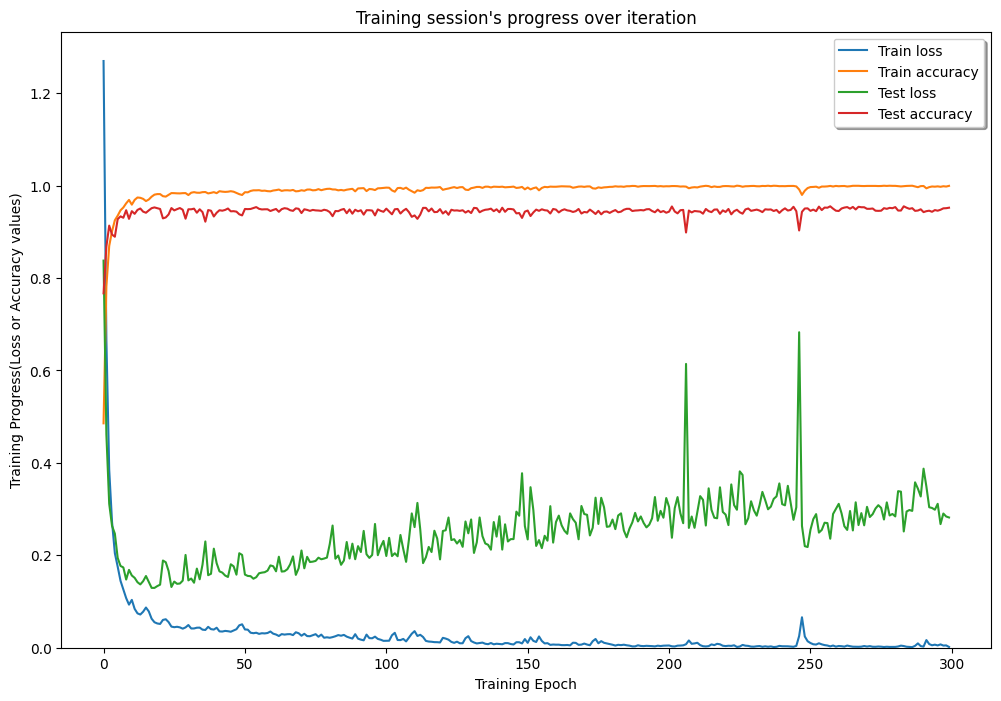

In [36]:
plot_curves(history=history2)

! Early stop !

In [37]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model3 = Sequential([
    LSTM(64, return_sequences=True, input_shape=(1, 561),
         kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    LSTM(32, kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(6, activation='softmax')
])

model3.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    X_train_lstm, y_train_cat,
    epochs=300,
    batch_size=256,
    validation_data=(X_test_lstm, y_test_cat),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)
    ],
    verbose=1
)

loss3, acc3 = model3.evaluate(X_test_lstm, y_test_cat, verbose=0)
print(f"\nAccuracy : {acc3*100:.2f}%")
print(f"Loss : {loss3*100:.2f}%")

Epoch 1/300


/home/hiba/HAR_models/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3059 - loss: 2.1036 - val_accuracy: 0.4096 - val_loss: 1.9272 - learning_rate: 5.0000e-04
Epoch 2/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4780 - loss: 1.7763 - val_accuracy: 0.7221 - val_loss: 1.5161 - learning_rate: 5.0000e-04
Epoch 3/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6162 - loss: 1.3964 - val_accuracy: 0.7516 - val_loss: 1.0994 - learning_rate: 5.0000e-04
Epoch 4/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6971 - loss: 1.0543 - val_accuracy: 0.7872 - val_loss: 0.8277 - learning_rate: 5.0000e-04
Epoch 5/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7510 - loss: 0.8358 - val_accuracy: 0.8368 - val_loss: 0.6642 - learning_rate: 5.0000e-04
Epoch 6/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8017 - loss: 0.7033 - val_accuracy: 0.8839 - val_loss: 0.5626 - learning_rate: 5.0000e-04
Epoch 7/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8419 - loss: 0.

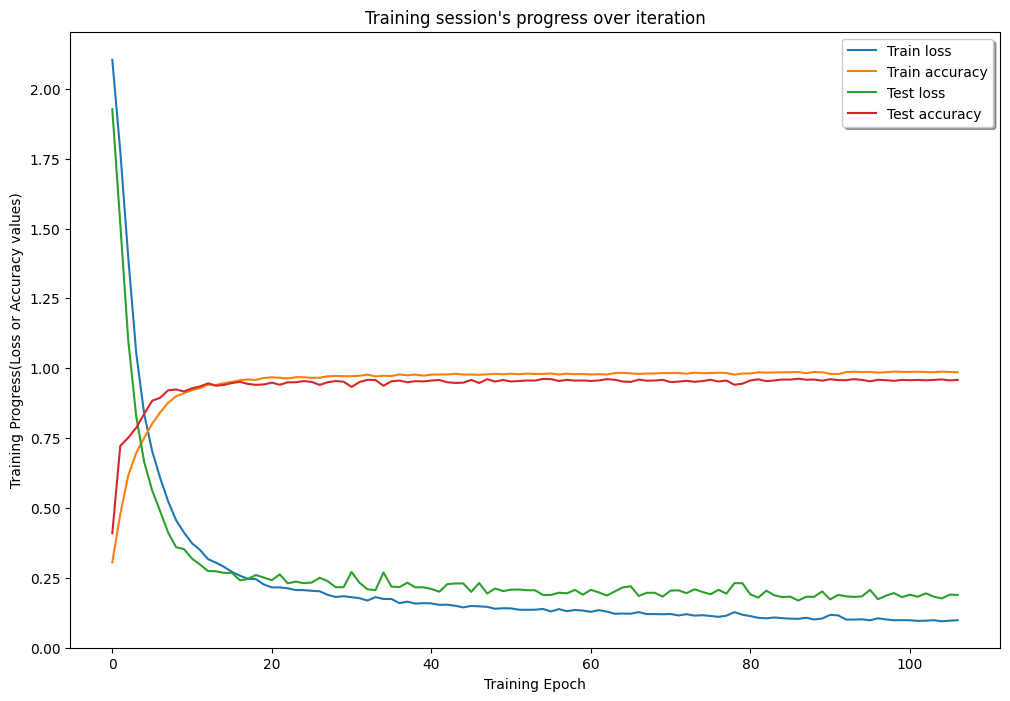

In [39]:
plot_curves(history=history3)